# Phase 2 — RandomCommunitySolver: Test Notebook

**No Gurobi licence required.**  All tests run locally.

| Group | Tests | What is verified |
|-------|-------|------------------|
| Interface | T1 | `CommunitySolverBase` conformance |
| action_space | T2–T4 | validity, caching, room-not-required |
| sample | T5–T9 | coverage, option validity, constraint satisfaction, reproducibility, ordering |
| no-good | T10–T12 | add, reject, duplicate handling, clear |
| stats | T13–T14 | tracking, reset |
| edge cases | T15 | max_attempts=0 |
| cross-instance | T16 | all 96 instances with communities |
| internals | T17 | `_community_action_space_size` |


In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('..'))

from src.utils.dataReader import PSTTReader
from src.hybrid.special_constraint_decomposer import SpecialConstraintDecomposer, _room_available
from src.hybrid.random_community_solver import RandomCommunitySolver, _assignment_to_nogood
from src.hybrid.community_solver_base import CommunitySolverBase
import pandas as pd
import matplotlib.pyplot as plt

INSTANCE = '../data/source/instances/agh-fal17.xml'
reader = PSTTReader(INSTANCE)
decomp = SpecialConstraintDecomposer(reader)
result = decomp.classify_classes()
communities = result.communities
solver = RandomCommunitySolver(reader, decomp, seed=42)

print(f'Instance  : {reader.problem_name}')
print(f'Classes   : {len(reader.classes)}')
print(f'Communities: {len(communities)}')
print(f'Community classes: {len(result.community)}')

Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288
Instance  : agh-fal17
Classes   : 5081
Communities: 31
Community classes: 409


---
## T1 — `CommunitySolverBase` interface conformance

In [2]:
assert isinstance(solver, CommunitySolverBase)
print('isinstance(solver, CommunitySolverBase) OK')

for m in ['action_space','sample','add_no_good','clear_no_goods','no_good_count','stats','reset_stats']:
    assert hasattr(solver, m), f'Missing: {m}'
print('All 7 abstract methods present OK')

isinstance(solver, CommunitySolverBase) OK
All 7 abstract methods present OK


---
## T2 — `action_space`: option validity

For each returned `(tidx, rid)`: `tidx` in range, `rid` in room_options, room available at that time.

In [3]:
rows = []
for cid in list(result.community)[:50]:
    cls           = reader.classes[cid]
    opts          = solver.action_space(cid)
    room_required = cls.get('room_required', True)
    room_ids      = {r['id'] for r in cls.get('room_options', [])}
    n_time_opts   = len(cls['time_options'])
    valid = True
    for tidx, rid in opts:
        if not (0 <= tidx < n_time_opts): valid = False
        if room_required and room_ids:
            if rid not in room_ids: valid = False
            tb = cls['time_options'][tidx]['optional_time_bits']
            if not _room_available(reader.rooms.get(rid, {}), tb): valid = False
        else:
            if rid is not None: valid = False
    rows.append({'CID': cid, 'Options': len(opts), 'Valid': valid})

df = pd.DataFrame(rows)
assert df['Valid'].all(), f"Invalid options found: {df[~df['Valid']]}"
print(f'T2 OK - checked {len(df)} classes, all options valid')
df.head(10)

T2 OK - checked 50 classes, all options valid


,CID,Options,Valid
0,1224,366,True
1,4667,609,True
2,1097,8702,True
3,1360,354,True
4,4647,3046,True
5,896,6,True
6,4713,300,True
7,4861,1584,True
8,4640,236,True
9,1621,385,True


---
## T3 — `action_space`: caching

In [4]:
for cid in list(result.community)[:20]:
    assert solver.action_space(cid) is solver.action_space(cid), f'{cid}: not cached'
print('T3 OK - action_space returns same object on repeat calls')

T3 OK - action_space returns same object on repeat calls


---
## T4 — `action_space`: room-not-required classes get `rid=None`

In [5]:
no_room = [cid for cid in reader.classes
           if not reader.classes[cid].get('room_required', True)
           or not reader.classes[cid].get('room_options')]
if no_room:
    for cid in no_room[:10]:
        for _, rid in solver.action_space(cid):
            assert rid is None, f'{cid}: expected rid=None, got {rid}'
    print(f'T4 OK - rid=None for {len(no_room)} room-not-required classes')
else:
    print('T4 SKIP - no room-not-required classes in this instance')

T4 OK - rid=None for 421 room-not-required classes


---
## T5 — `sample`: covers all community class IDs

In [6]:
for comm in communities:
    a = solver.sample(comm, max_attempts=500)
    if a is None: continue
    assert set(a.keys()) == comm.class_ids, \
        f'Community {comm.id}: covers {set(a.keys())} != {comm.class_ids}'
print(f'T5 OK - all {len(communities)} communities covered')

T5 OK - all 31 communities covered


---
## T6 — `sample`: returned options within `action_space`

In [7]:
s6 = RandomCommunitySolver(reader, decomp, seed=0)
n_viol = 0
for comm in communities:
    a = s6.sample(comm, max_attempts=500)
    if a is None: continue
    for cid, (tidx, rid) in a.items():
        if (tidx, rid) not in s6.action_space(cid):
            n_viol += 1
assert n_viol == 0
print('T6 OK - all sampled options within action_space')

T6 OK - all sampled options within action_space


---
## T7 — `sample`: special constraint satisfaction

In [8]:
s7 = RandomCommunitySolver(reader, decomp, seed=1)
rows7 = []
for comm in communities:
    a = s7.sample(comm, max_attempts=1000)
    if a is None:
        rows7.append({'Community': comm.id, 'Size': len(comm.class_ids), 'Result': 'exhausted'})
        continue
    ok = decomp.check_special_constraints(comm, a)
    rows7.append({'Community': comm.id, 'Size': len(comm.class_ids),
                  'Result': 'satisfied' if ok else 'VIOLATED'})

df7 = pd.DataFrame(rows7)
assert (df7['Result'] != 'VIOLATED').all(), f"Violations: {df7[df7['Result']=='VIOLATED']}"
print('T7 OK - no constraint violations')
df7['Result'].value_counts()

T7 OK - no constraint violations


Result
satisfied    26
exhausted     5
Name: count, dtype: int64

---
## T8 — `sample`: seed reproducibility

In [9]:
comm0 = communities[0]
sa = RandomCommunitySolver(reader, decomp, seed=99)
sb = RandomCommunitySolver(reader, decomp, seed=99)
sc = RandomCommunitySolver(reader, decomp, seed=100)

aa = sa.sample(comm0, max_attempts=500)
ab = sb.sample(comm0, max_attempts=500)
ac = sc.sample(comm0, max_attempts=500)

assert aa == ab, 'Same seed must give same result'
print('T8 OK - same seed produces same sample')
if aa is not None and ac is not None and aa != ac:
    print('T8 OK - different seeds produce different samples')

T8 OK - same seed produces same sample


---
## T9 — constraint-ordered assignment (ascending action-space size)

In [10]:
rows9 = []
for comm in communities:
    ordered = solver._order_by_constraint(comm)
    sizes   = [len(solver.action_space(cid)) for cid in ordered]
    assert sizes == sorted(sizes), f'Not ascending: {sizes}'
    rows9.append({'Community': comm.id, 'Min options': sizes[0] if sizes else 0,
                  'Max options': sizes[-1] if sizes else 0, 'Classes': len(comm.class_ids)})

df9 = pd.DataFrame(rows9)
print('T9 OK - all communities ordered by ascending action-space size')
df9.sort_values('Min options').head(10)

T9 OK - all communities ordered by ascending action-space size


,Community,Min options,Max options,Classes
0,0,1,1,2
15,15,1,742,7
12,12,1,794,25
8,8,1,8702,60
7,7,2,11794,9
26,26,10,13320,185
19,19,12,308,9
13,13,31,240,7
28,28,36,36,4
17,17,50,300,9


---
## T10 — no-good: add and reject

In [11]:
s10 = RandomCommunitySolver(reader, decomp, seed=7)
comm0 = communities[0]

a = s10.sample(comm0, max_attempts=500)
if a is None:
    print('T10 SKIP - community 0 exhausted')
else:
    assert s10.no_good_count(comm0.id) == 0
    s10.add_no_good(comm0.id, a)
    assert s10.no_good_count(comm0.id) == 1
    ng = _assignment_to_nogood(a)
    assert ng in s10._no_goods[comm0.id]

    # Verify not returned in subsequent samples
    returned_nogood = False
    for _ in range(200):
        a2 = s10.sample(comm0, max_attempts=500)
        if a2 is not None and a2 == a:
            returned_nogood = True
            break
    assert not returned_nogood
    print(f'T10 OK - no-good assignment not returned in 200 subsequent samples')

T10 OK - no-good assignment not returned in 200 subsequent samples


---
## T11 — no-good: multiple entries, duplicate handling

In [12]:
s11 = RandomCommunitySolver(reader, decomp, seed=8)
comm0 = communities[0]
seen = set()
for _ in range(5):
    a = s11.sample(comm0, max_attempts=500)
    if a is None: break
    s11.add_no_good(comm0.id, a)
    seen.add(_assignment_to_nogood(a))

assert s11.no_good_count(comm0.id) == len(seen)
if seen:
    first = {cid: (tidx, rid) for cid, tidx, rid in next(iter(seen))}
    s11.add_no_good(comm0.id, first)   # duplicate
    assert s11.no_good_count(comm0.id) == len(seen)   # still same count

print(f'T11 OK - {len(seen)} unique no-goods, duplicates not counted twice')

T11 OK - 1 unique no-goods, duplicates not counted twice


---
## T12 — `clear_no_goods`

In [13]:
s12 = RandomCommunitySolver(reader, decomp, seed=9)
for comm in communities[:3]:
    a = s12.sample(comm, max_attempts=300)
    if a: s12.add_no_good(comm.id, a)

s12.clear_no_goods(communities[0].id)
assert s12.no_good_count(communities[0].id) == 0
print('clear_no_goods(id) cleared only that community')

s12.clear_no_goods()
for comm in communities[:3]:
    assert s12.no_good_count(comm.id) == 0
print('T12 OK - clear_no_goods() cleared all')

clear_no_goods(id) cleared only that community
T12 OK - clear_no_goods() cleared all


---
## T13 — `stats`: tracking correctness

In [14]:
s13 = RandomCommunitySolver(reader, decomp, seed=13)
s13.reset_stats()
n_calls = 0
for comm in communities[:5]:
    s13.sample(comm, max_attempts=200)
    n_calls += 1

s = s13.stats()
assert s['total_sample_calls'] == n_calls
assert s['total_attempts'] == (
    s['special_constraint_rejections'] + s['no_good_rejections'] + s['successes']
)
print('T13 OK - stats accounting is balanced')
pd.DataFrame([s]).T.rename(columns={0: 'Value'})

T13 OK - stats accounting is balanced


,Value
total_sample_calls,5
total_attempts,204
special_constraint_rejections,200
no_good_rejections,0
successes,4
exhausted,1


---
## T14 — `reset_stats`

In [15]:
s13.reset_stats()
s = s13.stats()
assert all(v == 0 for v in s.values())
print('T14 OK - all stats zeroed')

T14 OK - all stats zeroed


---
## T15 — `sample` returns `None` when `max_attempts=0`

In [16]:
r = solver.sample(communities[0], max_attempts=0)
assert r is None
print('T15 OK - sample(max_attempts=0) returns None')

T15 OK - sample(max_attempts=0) returns None


---
## T16 — Cross-instance: all instances with communities

In [17]:
rows16 = []
paths = sorted(glob.glob('../data/source/**/*.xml', recursive=True))
for path in paths:
    r = PSTTReader(path)
    d = SpecialConstraintDecomposer(r)
    res = d.classify_classes()
    if not res.communities:
        continue
    s = RandomCommunitySolver(r, d, seed=0)
    n_ok = n_none = n_fail = 0
    for comm in res.communities:
        a = s.sample(comm, max_attempts=300)
        if a is None: n_none += 1
        elif d.check_special_constraints(comm, a): n_ok += 1
        else: n_fail += 1
    rows16.append({'Instance': r.problem_name, 'Communities': len(res.communities),
                   'Satisfied': n_ok, 'Exhausted': n_none, 'Violated': n_fail})

df16 = pd.DataFrame(rows16)
assert (df16['Violated'] == 0).all(), f"Violations in: {df16[df16['Violated']>0]}"
print(f'T16 OK - {len(df16)} instances with communities, 0 constraint violations')
df16

Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: iku-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: mary-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: muni-fi-spr16, Days: 7, Weeks: 15, Slots/Day: 288
Problem Name: muni-fsps-spr17, Days: 7, Weeks: 19, Slots/Day: 288
Problem Name: muni-pdf-spr16c, Days: 7, Weeks: 13, Slots/Day: 288
Problem Name: pu-llr-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: tg-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288
Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggos-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-h-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Weeks: 16, Slots/Day: 

,Instance,Communities,Satisfied,Exhausted,Violated
0,agh-fis-spr17,13,11,2,0
1,agh-ggis-spr17,5,3,2,0
2,bet-fal17,47,47,0,0
3,muni-fi-spr16,7,6,1,0
4,muni-pdf-spr16c,34,29,5,0
5,pu-llr-spr17,2,2,0,0
6,agh-fal17,31,26,5,0
7,agh-fis-spr17,13,11,2,0
8,agh-ggis-spr17,5,3,2,0
9,agh-ggos-spr17,6,6,0,0


---
## T17 — `_community_action_space_size`

In [18]:
rows17 = []
for comm in communities:
    size = solver._community_action_space_size(comm)
    expected = 1
    for cid in comm.class_ids:
        n = len(solver.action_space(cid))
        if n == 0: expected = 0; break
        expected *= n
    assert size == expected
    rows17.append({'Community': comm.id, 'Classes': len(comm.class_ids),
                   'Action space size': size})

df17 = pd.DataFrame(rows17).sort_values('Action space size', ascending=False)
print('T17 OK - _community_action_space_size matches product of individual sizes')
df17.head(10)

T17 OK - _community_action_space_size matches product of individual sizes


,Community,Classes,Action space size
26,26,185,4665595555578616084717134062088234964682083459...
8,8,60,4815582467217752903849662648452632310563139534...
12,12,25,1137774528161291286526165700334059520000000000...
7,7,9,93589902794965393966080416010304
1,1,12,4722366482869645213696
4,4,7,15562569781756991484
10,10,5,7131085423213689257
17,17,9,4687500000000000000
20,20,8,385745132985828000
2,2,8,147578905600000000


---
## Visualisations

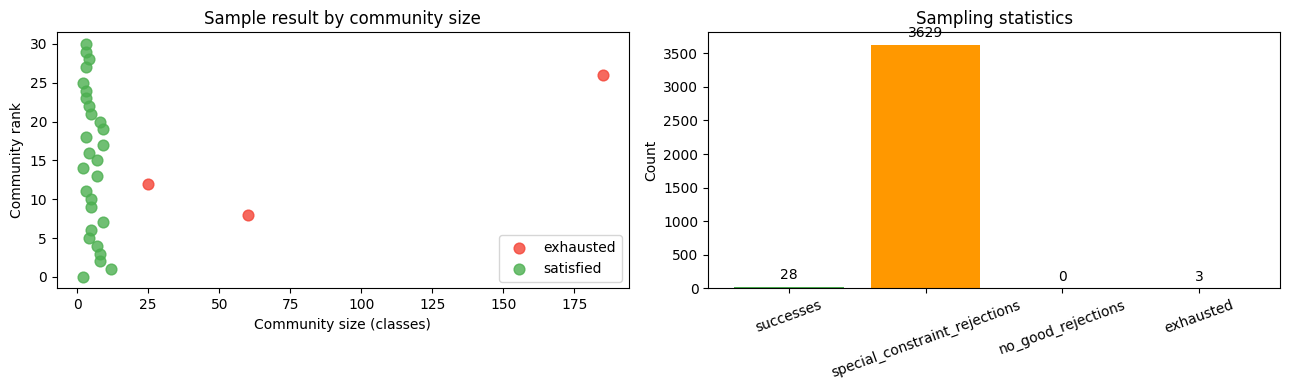

Saved: phase2_sampling_stats.png


In [19]:
# Stats across all communities
s_all = RandomCommunitySolver(reader, decomp, seed=42)
s_all.reset_stats()
sample_results = []
for comm in communities:
    a = s_all.sample(comm, max_attempts=1000)
    s_snap = s_all.stats()
    sample_results.append({
        'Community': comm.id,
        'Size': len(comm.class_ids),
        'Result': 'satisfied' if a is not None else 'exhausted',
        'ActionSpaceSize': s_all._community_action_space_size(comm),
    })

df_res = pd.DataFrame(sample_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: sample result by community size
colors = {'satisfied': '#4CAF50', 'exhausted': '#F44336'}
for res, grp in df_res.groupby('Result'):
    axes[0].scatter(grp['Size'], grp.index, label=res,
                    color=colors.get(res, 'gray'), s=60, alpha=0.8)
axes[0].set_xlabel('Community size (classes)')
axes[0].set_ylabel('Community rank')
axes[0].set_title('Sample result by community size')
axes[0].legend()

# Right: stats bar chart
s_final = s_all.stats()
keys = ['successes','special_constraint_rejections','no_good_rejections','exhausted']
vals = [s_final[k] for k in keys]
cols = ['#4CAF50','#FF9800','#9C27B0','#F44336']
bars = axes[1].bar(keys, vals, color=cols)
axes[1].bar_label(bars, padding=3)
axes[1].set_ylabel('Count')
axes[1].set_title('Sampling statistics')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('phase2_sampling_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase2_sampling_stats.png')

In [20]:
print('='*50)
print('ALL PHASE 2 TESTS PASSED')
print('='*50)

ALL PHASE 2 TESTS PASSED
